# CVRPTW — exact formulation with Pyomo + Gurobi

Model of the *Capacitated Vehicle Routing Problem with Time Windows*. Built step by step and solved with Gurobi.


## Mathematical formulation

### Sets
- $N$: all nodes, with $0$ as the depot
- $C = N \setminus \{0\}$: the customers

### Parameters
- $c_{ij}$: distance from node $i$ to node $j$
- $t_{ij}$: travel time from $i$ to $j$ (in Solomon, $t_{ij}=c_{ij}$)
- $q_i$: demand of node $i$
- $Q$: vehicle capacity
- $a_i,\ b_i$: opening and closing of the time window of node $i$
- $s_i$: service time of node $i$
- $K$: maximum number of vehicles
- $M$: big-M constant for the time constraints

### Variables
- $x_{ij}\in\{0,1\}$: 1 if a vehicle travels directly from $i$ to $j$
- $w_i\ge 0$: time at which service starts at node $i$
- $u_i\ge 0$: accumulated load of the vehicle when leaving node $i$

### Objective
$$\min \sum_{i\in N}\sum_{j\in N,\ j\ne i} c_{ij}\, x_{ij}$$

### Constraints
1. each customer is visited once (number of vans coming in each node is 1): $\sum_{i\ne j} x_{ij} = 1 \quad \forall j\in C$
2. each customer is visited once (number of vans coming out of each node is 1): $\sum_{j\ne i} x_{ij} = 1 \quad \forall i\in C$
3. no more than $K$ vehicles are used: $\sum_{j\in C} x_{0j} \le K$, and as many return as leave
4. time propagation (big-M): $w_i + s_i + t_{ij} - M\,(1-x_{ij}) \le w_j \quad \forall i\in N,\ \forall j\in C$
5. return to the depot before closes: $w_i + s_i + t_{i0} - M\,(1-x_{i0}) \le b_0 \quad \forall i\in C$
6. time windows: $a_i \le w_i \le b_i \quad \forall i\in N$
7. capacity propagation: $u_j \ge u_i + q_j - Q\,(1-x_{ij}) \quad \forall i\in N,\ \forall j\in C$
8. load bounds: $q_i \le u_i \le Q \quad \forall i\in N$

## Imports

In [86]:
import sys
import os


root = os.path.dirname(os.getcwd())
sys.path.append(root)

import pyomo.environ as pe
import pyomo.opt as po

from cvrptw.parser import parse_solomon

## Load the instance


In [87]:
instance = parse_solomon('../data/solomon/c101.txt')

print(instance)
print('depot:', instance.depot)

Instance(name='C101', vehicle_capacity=200.0, size=101)
depot: Node(index=0, x=40.0, y=50.0, demand=0.0, start_time=0.0, end_time=1236.0, service_time=0.0)


## SETS

$N$: all nodes (0 is the depot)

$C$: the customers (all nodes except the depot)

In [88]:
model = pe.ConcreteModel('cvrptw')

nodes = list(range(instance.size))         
customers = list(range(1, instance.size))

model.N = pe.Set(initialize=nodes, ordered=True)
model.C = pe.Set(initialize=customers, ordered=True)

print('N:', list(model.N))
print('C:', list(model.C))

N: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
C: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


## PARAMETERS


In [89]:
# distances and travel times (equal in solomon)
c = instance.distances

# data at each node
q = {i: instance.nodes[i].demand for i in nodes}
a = {i: instance.nodes[i].start_time for i in nodes}
b = {i: instance.nodes[i].end_time for i in nodes}
s = {i: instance.nodes[i].service_time for i in nodes}

# scalars
Q = instance.vehicle_capacity

# use the fleet size from the instance if it has one otherwise one vehicle per customer
if instance.num_vehicles is not None:
    K = instance.num_vehicles
else:
    K = len(customers)

# all pairs of nodes connections
links = [(i, j) for i in nodes for j in nodes if i != j]

# links that arrive at a customer
customer_links = [(i, j) for (i, j) in links if j != 0]

# big-M (The worst case of the time constraint)
M = max(b[i] for i in nodes) + max(s[i] for i in nodes) + max(c[i][j] for (i, j) in links)

print(f"capacity Q: {Q} | vehicles K: {K}| big-M: {M}| links: {len(links)}")

capacity Q: 200.0 | vehicles K: 25| big-M: 1422.1769203083568| links: 10100


## VARIABLES

$x_{ij}$: binary, defined only over the links (pairs $i\ne j$).

$w_i$: service start time, bounded directly by the window $[a_i, b_i]$ (constraint 6 is built into the bounds).

$u_i$: accumulated load, bounded in $[q_i, Q]$. We fix $u_0=0$ (the vehicle leaves the depot empty).

In [90]:
model.L = pe.Set(initialize=links, dimen=2)

model.x = pe.Var(model.L, within=pe.Binary)

# w bounded by each node time window
def w_bounds(m, i):
    return (a[i], b[i])
model.w = pe.Var(model.N, within=pe.NonNegativeReals, bounds=w_bounds)

# u bounded between the node demand and the capacity
def u_bounds(m, i):
    return (q[i], Q)
model.u = pe.Var(model.N, within=pe.NonNegativeReals, bounds=u_bounds)

# the vehicle leaves the depot empty
model.u[0].fix(0)

## OBJECTIVE

Minimize the total distance travelled.

$$\min \sum_{(i,j)\in L} c_{ij}\, x_{ij}$$

In [91]:
def obj_rule(m):
    return sum(c[i][j] * m.x[i, j] for (i, j) in m.L)
model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize)

## CONSTRAINTS

### Degree: visit each customer once

Exactly one link enters and one link leaves each customer. At most $K$ vehicles leave the depot, and as many return as left.

In [92]:
# 1  one link enters each customer j
def in_customer_rule(m, j):
    return sum(m.x[i, j] for i in m.N if i != j) == 1
model.in_customer = pe.Constraint(model.C, rule=in_customer_rule)

# 2  one link leaves each customer i
def out_customer_rule(m, i):
    return sum(m.x[i, j] for j in m.N if j != i) == 1
model.out_customer = pe.Constraint(model.C, rule=out_customer_rule)

# 3  no more than K vehicles leave
def depot_out_rule(m):
    return sum(m.x[0, j] for j in m.C) <= K
model.depot_out = pe.Constraint(rule=depot_out_rule)

# as many vehicles as left return
def depot_balance_rule(m):
    return sum(m.x[0, j] for j in m.C) == sum(m.x[i, 0] for i in m.C)
model.depot_balance = pe.Constraint(rule=depot_balance_rule)

### Time: windows and subtour elimination

If link $i\to j$ is used, service at $j$ cannot start before servicing $i$ and travelling to $j$. When $x_{ij}=0$ the term $-M(1-x_{ij})$ deactivates the constraint. Also force the return to the depot before $b_0$.

In [93]:
# 4  time propagation towards each customer j
def time_rule(m, i, j):
    return m.w[i] + s[i] + c[i][j] - M * (1 - m.x[i, j]) <= m.w[j]
model.time = pe.Constraint(customer_links, rule=time_rule)

# 5  return to the depot before it closes
def return_rule(m, i):
    return m.w[i] + s[i] + c[i][0] - M * (1 - m.x[i, 0]) <= b[0]
model.return_depot = pe.Constraint(model.C, rule=return_rule)

### Load: vehicle capacity

If link $i\to j$ is used, the load accumulated on arriving at $j$ is that of $i$ plus the demand of $j$. Since $u_j$ is bounded by $Q$, no route can exceed the capacity.

In [94]:
# 7  load propagation towards each customer j
def load_rule(m, i, j):
    return m.u[i] + q[j] - Q * (1 - m.x[i, j]) <= m.u[j]
model.capacity = pe.Constraint(customer_links, rule=load_rule)

## Solve


In [ ]:
solver = po.SolverFactory('gurobi_direct')
results = solver.solve(model, tee=True)

print()
print('status    :', results.solver.status)
print('condition :', results.solver.termination_condition)
print('optimal cost:', round(pe.value(model.obj), 4))

## Extract and validate the solution

We rebuild the routes from the active links ($x_{ij}=1$) and put them into Solution class. Then we validate the solution.

In [ ]:
from cvrptw.model import Solution
from cvrptw import evaluation as ev

# active links
active = [(i, j) for (i, j) in links if pe.value(model.x[i, j])==1]

succesors = {i: j for (i, j) in active if i != 0}
routes = []
for first in [j for (i, j) in active if i == 0]:
    route = [first]
    node = first
    while succesors[node] != 0:
        node = succesors[node]
        route.append(node)
    routes.append(route)

sol = Solution(instance, routes)
print('routes:', routes)
print('vehicles used:', sol.num_vehicles)
print('cost from gurobi     :', round(pe.value(model.obj), 4))
print('cost from evaluation :', round(sol.distance(), 4))
print('feasible from evaluation:', sol.is_feasible())

routes: [[5, 3, 7, 8, 10, 11, 9, 6, 4, 2, 1, 75], [13, 17, 18, 19, 15, 16, 14, 12], [20, 24, 25, 27, 29, 30, 28, 26, 23, 22, 21], [32, 33, 31, 35, 37, 38, 39, 36, 34], [43, 42, 41, 40, 44, 46, 45, 48, 51, 50, 52, 49, 47], [57, 55, 54, 53, 56, 58, 60, 59], [67, 65, 63, 62, 74, 72, 61, 64, 68, 66, 69], [81, 78, 76, 71, 70, 73, 77, 79, 80], [90, 87, 86, 83, 82, 84, 85, 88, 89, 91], [98, 96, 95, 94, 92, 93, 97, 100, 99]]
vehicles used: 10
cost from gurobi     : 828.9369
cost from evaluation : 828.9369
feasible from evaluation: True


## Visualization


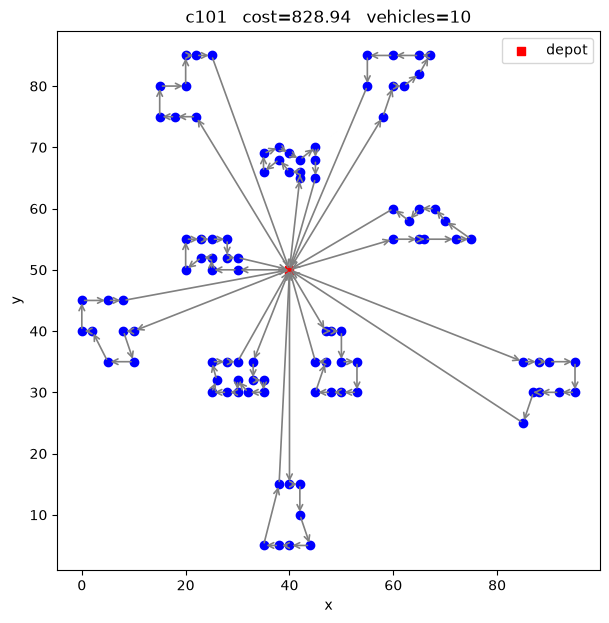

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

# nodes
for i in nodes:
    node = instance.nodes[i]
    if i == 0:
        ax.scatter(node.x, node.y, c='red', marker='s', label='depot')
    else:
        ax.scatter(node.x, node.y, c='blue')

# links
for (i, j) in active:
    ax.annotate('', xy=(instance.nodes[j].x, instance.nodes[j].y), xytext=(instance.nodes[i].x, instance.nodes[i].y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.set_title(f'{instance.name}   cost={pe.value(model.obj):.2f}   vehicles={sol.num_vehicles}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()